# A7 IndoBERT Training (GPU)

Melatih IndoBERT (aspect + polarity) hanya pada train/validation melalui
`sipature_ml.indobert.run_indobert_training`. Ikuti `docs/indobert-training-runbook.md`.

**Sebelum mulai:** Runtime > Change runtime type > **T4 GPU** (atau lebih tinggi).

**PENTING (locked-test prohibition):** A7 HANYA boleh membaca
`train_silver_v1.jsonl`, `validation_silver_v1.jsonl`, dan `split_manifest_silver_v1.json`.
Jangan pernah menyalin/membaca `test_silver_v1.jsonl` di notebook ini.


## Step 1 — Mount Google Drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 2 — Konfigurasi path & parameter


In [2]:
# ============================================================
# CONFIGURATION CELL — satu-satunya tempat mengubah parameter.
# ============================================================
from datetime import datetime, timezone
from pathlib import Path

DRIVE_ROOT = Path("/content/drive/MyDrive/SIPATURE")
DRIVE_SPLIT_DIR = DRIVE_ROOT / "data" / "splits"

PROJECT_DIR = Path("/content/hackathon/ml")
SPLIT_DIR = PROJECT_DIR / "data" / "splits"
ARTIFACT_DIR = DRIVE_ROOT  # run_indobert_training menulis ke <artifact>/runs/<run_id>

RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d-%H%M_indobert-silver-v1")
RUN_DIR = ARTIFACT_DIR / "runs" / RUN_ID

print("Drive root:", DRIVE_ROOT)
print("Sumber split:", DRIVE_SPLIT_DIR)
print("Split dir (lokal):", SPLIT_DIR)
print("Run ID:", RUN_ID)
print("Output run dir:", RUN_DIR)


Drive root: /content/drive/MyDrive/SIPATURE
Sumber split: /content/drive/MyDrive/SIPATURE/data/splits
Split dir (lokal): /content/hackathon/ml/data/splits
Run ID: 20260813-1050_indobert-silver-v1
Output run dir: /content/drive/MyDrive/SIPATURE/runs/20260813-1050_indobert-silver-v1


## Step 3 — Verifikasi GPU


In [3]:
!nvidia-smi


Thu Aug 13 10:45:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 4 — Clone repository dari GitHub


In [4]:
from google.colab import userdata
import base64
import os
import shutil
import subprocess

token = userdata.get("GITHUB_TOKEN")
assert token, "GITHUB_TOKEN tidak ditemukan di Colab Secrets"

credentials = f"x-access-token:{token}"
authorization = base64.b64encode(credentials.encode()).decode()

repo_dir = "/content/hackathon"
shutil.rmtree(repo_dir, ignore_errors=True)

environment = os.environ.copy()
environment["GIT_CONFIG_COUNT"] = "1"
environment["GIT_CONFIG_KEY_0"] = "http.extraHeader"
environment["GIT_CONFIG_VALUE_0"] = f"Authorization: Basic {authorization}"

result = subprocess.run(
    ["git", "clone", "https://github.com/jodypangaribuan/hackathon.git", repo_dir],
    env=environment,
    text=True,
    capture_output=True,
)

print("Return code:", result.returncode)
print(result.stdout)
print(result.stderr)

assert result.returncode == 0, "Clone gagal. Periksa izin token GitHub."


Return code: 0

Cloning into '/content/hackathon'...



## Step 5 — Verifikasi commit terbaru (git log)


In [5]:
%cd /content/hackathon/ml
!git log --oneline -3


/content/hackathon/ml
fcb63fa (HEAD -> main, origin/main, origin/HEAD) refactor: tidy notebook 06 for re-run (step markers, fix split path and stale run id)
cae4850 docs: add step markers to notebook 05
f7a562c docs: record notebook 05 baseline completion and mark keyword/TF-IDF artifacts done


## Step 6 — Uninstall torchvision + install dependencies


In [6]:
%cd /content/hackathon/ml
!python -m pip uninstall -y torchvision
!python -m pip install -r requirements-colab.lock.txt
!python -m pip install --no-deps -e .


/content/hackathon/ml
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 109.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 119.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

**RESTART WAJIB.** Setelah install, restart runtime agar numpy/torch lama tidak
ter-cache di memori (kegagalan umum: `cannot import name '_center'`).

1. **Runtime > Restart session**
2. Jalankan ulang **Step 1** (mount) dan **Step 2** (config)
3. Step 3–6 **tidak perlu diulang** (repo & packages sudah tersimpan di disk)

Lalu lanjut ke **Step 7**.


## Step 7 — Verifikasi versi package & GPU (setelah restart)


In [3]:
import importlib.util
import torch
import transformers
import datasets
import accelerate

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Accelerate:", accelerate.__version__)
print("CUDA tersedia:", torch.cuda.is_available())
print("Torchvision ditemukan:", importlib.util.find_spec("torchvision") is not None)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

from transformers import BertForSequenceClassification
print("BertForSequenceClassification berhasil diimpor: OK")


PyTorch: 2.7.1+cu126
Transformers: 4.53.2
Datasets: 3.6.0
Accelerate: 1.8.1
CUDA tersedia: True
Torchvision ditemukan: False
GPU: Tesla T4
BertForSequenceClassification berhasil diimpor: OK


## Step 8 — Copy split dari Drive (train/validation/manifest saja)


In [4]:
# Salin train/validation + manifest dari Drive. TEST TIDAK BOLEH disalin/dibaca.
import shutil
from pathlib import Path

SPLIT_DIR.mkdir(parents=True, exist_ok=True)

files_to_copy = [
    "train_silver_v1.jsonl",
    "validation_silver_v1.jsonl",
    "split_manifest_silver_v1.json",
]

for filename in files_to_copy:
    source = DRIVE_SPLIT_DIR / filename
    assert source.is_file(), f"File tidak ditemukan di Drive: {source}"
    shutil.copy2(source, SPLIT_DIR / filename)
    print(f"Disalin: {filename}")

print("\n(test_silver_v1.jsonl sengaja TIDAK disalin — locked-test policy)")


Disalin: train_silver_v1.jsonl
Disalin: validation_silver_v1.jsonl
Disalin: split_manifest_silver_v1.json

(test_silver_v1.jsonl sengaja TIDAK disalin — locked-test policy)


## Step 9 — Import modul sipature_ml


In [5]:
import sys
from pathlib import Path

source_dir = PROJECT_DIR / "src"
assert source_dir.is_dir(), "Folder source SIPATURE tidak ditemukan."

if str(source_dir) not in sys.path:
    sys.path.insert(0, str(source_dir))

import sipature_ml

print("Modul SIPATURE berhasil dimuat dari:")
print(sipature_ml.__file__)


Modul SIPATURE berhasil dimuat dari:
/content/hackathon/ml/src/sipature_ml/__init__.py


## Step 10 — Verifikasi hash split & validasi config IndoBERT


In [6]:
import json
from pathlib import Path

from sipature_ml.config import load_config
from sipature_ml.indobert import (
    validate_indobert_config,
    verify_training_split_hashes,
)

manifest_path = SPLIT_DIR / "split_manifest_silver_v1.json"
assert manifest_path.is_file(), f"Manifest tidak ditemukan: {manifest_path}"

manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
assert manifest["test_is_locked"], "Manifest split tidak terkunci"

verified = verify_training_split_hashes(split_dir=SPLIT_DIR, manifest=manifest)
print("Validasi hash train/validation berhasil:")
for split, digest in verified.items():
    print(f"  {split}: {digest}")

training_config = load_config("training")
indobert_config = validate_indobert_config(training_config)

print("\nModel ID :", indobert_config["model_id"])
print("Revision  :", indobert_config["revision"])
print("Max length:", indobert_config["max_length"])
print("Batch size:", indobert_config["batch_size"])
print("Epochs    :", indobert_config["epochs"])
print("Learning rate:", indobert_config["learning_rate"])
print("Mixed precision:", indobert_config["mixed_precision"])


Validasi hash train/validation berhasil:
  train: 31c31803be592a3c91576f42abbc3fcf562d2f82c126b2856848e88639ab3fc4
  validation: 7c2f5f911ea33c6854ad1adc21e41a58befb6b24b31cb5ef2b8e03b7b771477c

Model ID : indobenchmark/indobert-base-p1
Revision  : c2cd0b51ddce6580eb35263b39b0a1e5fb0a39e2
Max length: 192
Batch size: 16
Epochs    : 4
Learning rate: 2e-05
Mixed precision: fp16


## Step 11 — Download tokenizer & cek konsistensi model


In [7]:
from transformers import BertTokenizer, AutoConfig

MODEL_ID = indobert_config["model_id"]
MODEL_REVISION = indobert_config["revision"]

print("Mengunduh tokenizer...")
tokenizer = BertTokenizer.from_pretrained(MODEL_ID, revision=MODEL_REVISION)
print("Tokenizer vocab size:", tokenizer.vocab_size)

model_config = AutoConfig.from_pretrained(MODEL_ID, revision=MODEL_REVISION)
print("Model type:", model_config.model_type)
print("Embedding vocab size:", model_config.vocab_size)
print("Max position embeddings:", model_config.max_position_embeddings)

assert model_config.vocab_size >= tokenizer.vocab_size
assert indobert_config["max_length"] <= model_config.max_position_embeddings

print("\nKonfigurasi model & tokenizer konsisten (vocab & max_length aman).")


Mengunduh tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Tokenizer vocab size: 30521
Model type: bert
Embedding vocab size: 50000
Max position embeddings: 512

Konfigurasi model & tokenizer konsisten (vocab & max_length aman).


## Step 12 — Token-length coverage


In [8]:
import json
from pathlib import Path

from sipature_ml.indobert import read_jsonl, token_length_summary

records_by_split = {
    "train": read_jsonl(SPLIT_DIR / "train_silver_v1.jsonl"),
    "validation": read_jsonl(SPLIT_DIR / "validation_silver_v1.jsonl"),
}

coverage_report = {}
for split_name, records in records_by_split.items():
    encoded = tokenizer(
        [record["text"] for record in records],
        add_special_tokens=True,
        truncation=False,
        padding=False,
    )
    coverage_report[split_name] = token_length_summary(
        [len(ids) for ids in encoded["input_ids"]],
        max_length=indobert_config["max_length"],
    )

print(json.dumps(coverage_report, indent=2))


{
  "train": {
    "records": 922,
    "max_length": 192,
    "p50_tokens": 23,
    "p90_tokens": 97,
    "p95_tokens": 139,
    "p99_tokens": 304,
    "maximum_tokens": 544,
    "records_within_max_length": 896,
    "coverage_at_max_length": 0.9718004338394793
  },
  "validation": {
    "records": 196,
    "max_length": 192,
    "p50_tokens": 23,
    "p90_tokens": 74,
    "p95_tokens": 130,
    "p99_tokens": 319,
    "maximum_tokens": 525,
    "records_within_max_length": 192,
    "coverage_at_max_length": 0.9795918367346939
  }
}


## Step 13 — Build targets & severity gate preview


In [9]:
from collections import Counter

from sipature_ml.config import load_config
from sipature_ml.indobert import (
    build_aspect_targets,
    build_polarity_instances,
    build_severity_instances,
    severity_support_gate,
)

taxonomy = load_config("taxonomy")
aspects = sorted(taxonomy["aspect_definitions"])

aspect_targets = {
    split: build_aspect_targets(records, aspects)
    for split, records in records_by_split.items()
}
polarity_instances = {
    split: build_polarity_instances(records)
    for split, records in records_by_split.items()
}
severity_instances = {
    split: build_severity_instances(records)
    for split, records in records_by_split.items()
}

print("Aspect detection — jumlah review:")
for split in ("train", "validation"):
    print(f"  {split}: {len(aspect_targets[split])}")

print("\nPolarity instances:")
for split in ("train", "validation"):
    counts = Counter(p["label"] for p in polarity_instances[split])
    print(f"  {split}: {len(polarity_instances[split])} -> {dict(counts)}")

gate = severity_support_gate(
    train_instances=severity_instances["train"],
    validation_instances=severity_instances["validation"],
    min_train_per_class=indobert_config["severity_min_train_per_class"],
    min_validation_per_class=indobert_config["severity_min_validation_per_class"],
)
print("\nSeverity gate:")
print(json.dumps(gate, indent=2))


Aspect detection — jumlah review:
  train: 922
  validation: 196

Polarity instances:
  train: 1244 -> {1: 422, 0: 521, 2: 301}
  validation: 260 -> {0: 107, 1: 91, 2: 62}

Severity gate:
{
  "supported": false,
  "train_support": {
    "low": 208,
    "medium": 195,
    "high": 19
  },
  "validation_support": {
    "low": 38,
    "medium": 47,
    "high": 6
  },
  "minimum_train_per_class": 20,
  "minimum_validation_per_class": 5,
  "unsupported_classes": [
    "high"
  ]
}


## Step 14 — Jalankan training IndoBERT (aspect + polarity)


In [10]:
import json
import torch

from sipature_ml.indobert import run_indobert_training

print("Run ID:", RUN_ID)
print("Input  :", SPLIT_DIR)
print("Output :", RUN_DIR)
print("GPU    :", torch.cuda.get_device_name(0))

assert torch.cuda.is_available(), "CUDA GPU tidak tersedia."
assert not RUN_DIR.exists(), f"Run ID sudah ada: {RUN_DIR}"

summary = run_indobert_training(
    split_dir=SPLIT_DIR,
    artifact_dir=ARTIFACT_DIR,
    run_id=RUN_ID,
)

print("\nTRAINING SELESAI")
print(json.dumps(summary, indent=2, default=str))


Run ID: 20260813-1050_indobert-silver-v1
Input  : /content/hackathon/ml/data/splits
Output : /content/drive/MyDrive/SIPATURE/runs/20260813-1050_indobert-silver-v1
GPU    : Tesla T4


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Macro F1
1,1.210000,1.045974,0.281982
2,0.955800,0.911112,0.303958
3,0.803300,0.815268,0.379969
4,0.716800,0.782394,0.401225


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,0.985600,0.776207,0.645347
2,0.710800,0.697441,0.677918
3,0.545900,0.691214,0.703925
4,0.439300,0.696265,0.704404



TRAINING SELESAI
{
  "run_id": "20260813-1050_indobert-silver-v1",
  "status": "trained_train_validation_only",
  "test_read": false,
  "reference_label_type": "ai_assisted_weak_supervision_silver",
  "split_version": "silver-split-1.0.0",
  "input_hashes": {
    "train": "31c31803be592a3c91576f42abbc3fcf562d2f82c126b2856848e88639ab3fc4",
    "validation": "7c2f5f911ea33c6854ad1adc21e41a58befb6b24b31cb5ef2b8e03b7b771477c"
  },
  "token_length_coverage": {
    "train": {
      "records": 922,
      "max_length": 192,
      "p50_tokens": 23,
      "p90_tokens": 97,
      "p95_tokens": 139,
      "p99_tokens": 304,
      "maximum_tokens": 544,
      "records_within_max_length": 896,
      "coverage_at_max_length": 0.9718004338394793
    },
    "validation": {
      "records": 196,
      "max_length": 192,
      "p50_tokens": 23,
      "p90_tokens": 74,
      "p95_tokens": 130,
      "p99_tokens": 319,
      "maximum_tokens": 525,
      "records_within_max_length": 192,
      "coverage_at

## Step 15 — Verifikasi hasil run (summary + hash + kurva)


Status: trained_train_validation_only
Test read: False
Split version: silver-split-1.0.0
Severity gate supported: False

[aspect] best_metric=0.4012246461923619
  eval_macro_f1=0.4012246461923619

[polarity] best_metric=0.7044036969463576
  eval_macro_f1=0.7044036969463576

Offline reload smoke test:
  aspect: passed=True, local_files_only=True
  polarity: passed=True, local_files_only=True

Artifact hash check: 65 file, 0 masalah

Kurva training:


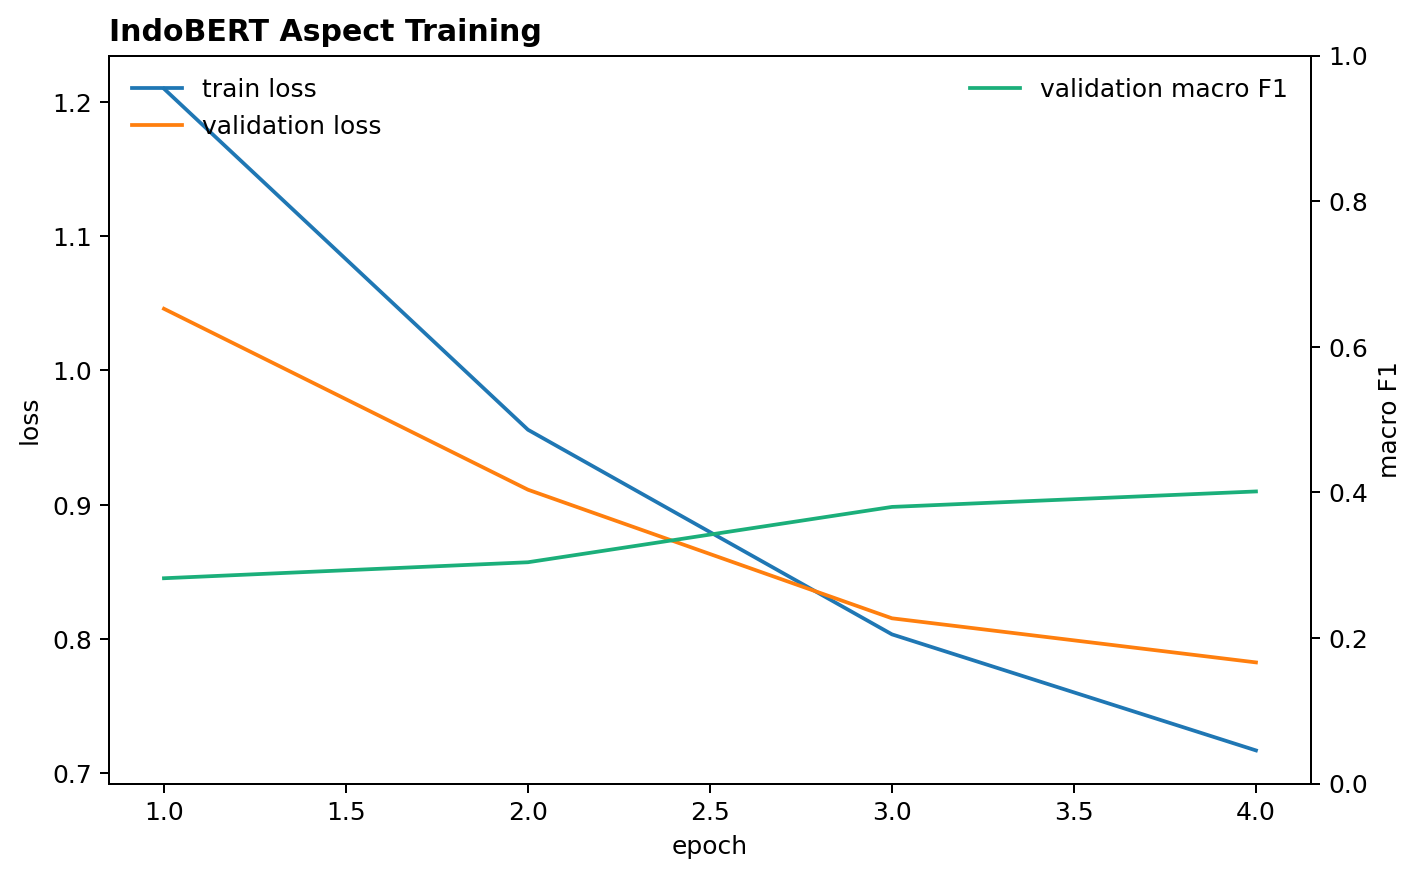

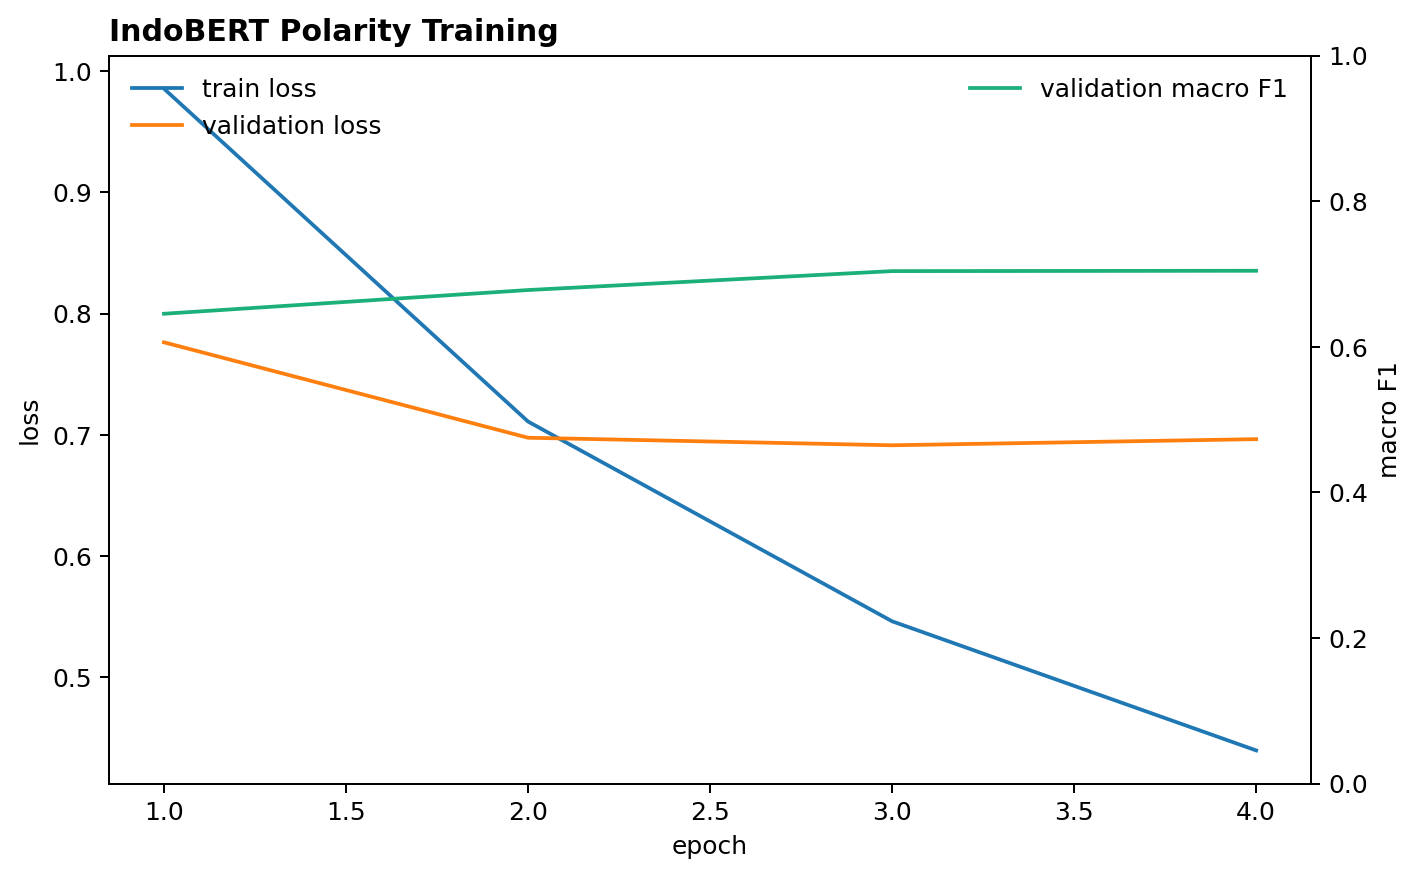

In [11]:
import json
from pathlib import Path

from IPython.display import Image, display
from sipature_ml.manifest import sha256_file

run_dir = RUN_DIR
assert run_dir.is_dir(), f"Run dir tidak ditemukan: {run_dir}"

summary = json.loads((run_dir / "summary.json").read_text(encoding="utf-8"))

print("Status:", summary["status"])
print("Test read:", summary["test_read"])
print("Split version:", summary["split_version"])
print("Severity gate supported:", summary["severity_gate"]["supported"])

for task, result in summary["tasks"].items():
    if "metrics" in result:
        metrics = result["metrics"]
        print(f"\n[{task}] best_metric={result['best_metric']}")
        print(f"  eval_macro_f1={metrics.get('eval_macro_f1')}")

print("\nOffline reload smoke test:")
for task, smoke in summary["offline_reload_smoke"].items():
    print(f"  {task}: passed={smoke['passed']}, local_files_only={smoke['local_files_only']}")

# Verifikasi hash artifact terhadap manifest.json
manifest = json.loads((run_dir / "manifest.json").read_text(encoding="utf-8"))
artifact_hashes = manifest.get("artifact_hashes", {})
errors = []
for relative, expected in artifact_hashes.items():
    path = run_dir / relative
    if not path.is_file():
        errors.append(f"missing: {relative}")
    elif sha256_file(path) != expected:
        errors.append(f"hash mismatch: {relative}")
print(f"\nArtifact hash check: {len(artifact_hashes)} file, {len(errors)} masalah")
for error in errors:
    print("  -", error)

print("\nKurva training:")
for task in ("aspect", "polarity"):
    history = run_dir / task / "training-history.png"
    if history.is_file():
        display(Image(filename=str(history)))


## Step 16 — Build evidence bundle ke Drive


In [12]:
import shutil
from pathlib import Path

evidence_dir = DRIVE_ROOT / f"{RUN_ID}_evidence"
if evidence_dir.exists():
    shutil.rmtree(evidence_dir)
evidence_dir.mkdir(parents=True)

files_to_copy = {
    "summary.json": RUN_DIR / "summary.json",
    "manifest.json": RUN_DIR / "manifest.json",
    "environment.json": RUN_DIR / "environment.json",
    "token-length-coverage.json": RUN_DIR / "token-length-coverage.json",
    "aspect-metrics.json": RUN_DIR / "aspect" / "metrics.json",
    "aspect-trainer-log.json": RUN_DIR / "aspect" / "trainer-log.json",
    "aspect-training-history.png": RUN_DIR / "aspect" / "training-history.png",
    "aspect-model-config.json": RUN_DIR / "aspect" / "model" / "config.json",
    "polarity-metrics.json": RUN_DIR / "polarity" / "metrics.json",
    "polarity-trainer-log.json": RUN_DIR / "polarity" / "trainer-log.json",
    "polarity-training-history.png": RUN_DIR / "polarity" / "training-history.png",
    "polarity-model-config.json": RUN_DIR / "polarity" / "model" / "config.json",
}

for output_name, source in files_to_copy.items():
    if not source.is_file():
        print(f"(skip, tidak ada) {output_name}")
        continue
    shutil.copy2(source, evidence_dir / output_name)

print("Evidence dir:", evidence_dir)
for path in sorted(evidence_dir.iterdir()):
    print(f"  {path.name}: {path.stat().st_size:,} byte")


Evidence dir: /content/drive/MyDrive/SIPATURE/20260813-1050_indobert-silver-v1_evidence
  aspect-metrics.json: 192 byte
  aspect-model-config.json: 1,547 byte
  aspect-trainer-log.json: 1,926 byte
  aspect-training-history.png: 82,136 byte
  environment.json: 1,198 byte
  manifest.json: 8,533 byte
  polarity-metrics.json: 190 byte
  polarity-model-config.json: 1,044 byte
  polarity-trainer-log.json: 1,926 byte
  polarity-training-history.png: 77,334 byte
  summary.json: 3,375 byte
  token-length-coverage.json: 538 byte


## Step 17 — Run summary


In [13]:
import json
from pathlib import Path

summary = json.loads((RUN_DIR / "summary.json").read_text(encoding="utf-8"))

print("RUN ID:", summary["run_id"])
print("STATUS:", summary["status"])
print("SPLIT VERSION:", summary["split_version"])
print("REFERENCE LABEL:", summary["reference_label_type"])
print("TEST READ:", summary["test_read"])
print("SEVERITY GATE:", summary["severity_gate"])

print("\nRUN DIR   :", RUN_DIR)
print("EVIDENCE DIR:", DRIVE_ROOT / f"{RUN_ID}_evidence")

print("\nREMINDER: jangan laporkan metrik locked-test dari run ini.")
print("Bekukan run + threshold dulu, lalu jalankan A8 untuk evaluasi locked-test sekali.")


RUN ID: 20260813-1050_indobert-silver-v1
STATUS: trained_train_validation_only
SPLIT VERSION: silver-split-1.0.0
REFERENCE LABEL: ai_assisted_weak_supervision_silver
TEST READ: False
SEVERITY GATE: {'minimum_train_per_class': 20, 'minimum_validation_per_class': 5, 'supported': False, 'train_support': {'high': 19, 'low': 208, 'medium': 195}, 'unsupported_classes': ['high'], 'validation_support': {'high': 6, 'low': 38, 'medium': 47}}

RUN DIR   : /content/drive/MyDrive/SIPATURE/runs/20260813-1050_indobert-silver-v1
EVIDENCE DIR: /content/drive/MyDrive/SIPATURE/20260813-1050_indobert-silver-v1_evidence

REMINDER: jangan laporkan metrik locked-test dari run ini.
Bekukan run + threshold dulu, lalu jalankan A8 untuk evaluasi locked-test sekali.
